# State Reducers

## Review
We covered a few different ways to define LangGraph state schema (`state_schema.ipynb`), including `TypedDict`, `Dataclasses`, or `Pydantic`.

## Goals
Now, we're going to dive into reducers, which specify how state updates are performed on specific keys/channels in the state schema.

## Default Overwriting State
Let's use a `TypedDict` as our state schema.

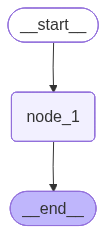

---Node 1---


{'foo': 2}

In [12]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.errors import InvalidUpdateError

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state["foo"] + 1}

# Build Graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"foo": 1})

## Branching
Let's look at a case where our nodes branch.

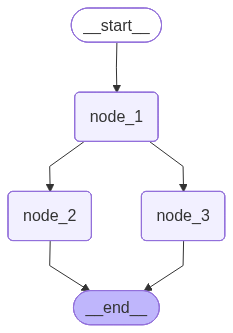

---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


In [13]:
class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state["foo"] + 1}

def node_2(state):
    print("---Node 2---")
    return {"foo": state["foo"] + 1}

def node_3(state):
    print("---Node 3---")
    return {"foo": state["foo"] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    graph.invoke({"foo": 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")

We see a problem. Node 1 branches to nodes 2 and 3. Nodes 2 and 3 run in parallel, which means they run in the same step of the graph.

They both attempt to overwrite the state within the same step.

## Reducers
Reducers give us a general way to address this problem. They specify how to perform updates. 

We can use the `Annotated` type to specify a reducer function. For example, in this case let's append the value returned from each node rather than overwriting them.

We just need a reducer that can perform this: `operator.add`. It is a function from Python built-in operator module. When `operator.add` is applied to lists, it performs list concatenation.

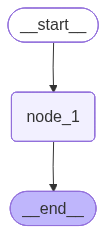

---Node 1---


{'foo': [1, 2]}

In [14]:
from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state["foo"][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"foo": [1]})

Now, our state key `foo` is a list. This `operator.add` reducer function will append updates from each node to this list.

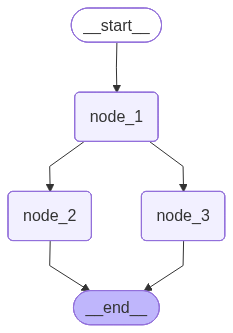

---Node 1---
---Node 2---
---Node 3---


{'foo': [1, 2, 3, 3]}

In [15]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [state["foo"][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"foo": [state["foo"][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"foo": [state["foo"][-1] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"foo": [1]})


We can see that updates in nodes 2 and 3 are performed concurrently because they are in the same step.

## Custom Reducers
To address cases like NoneType, we can also define custom reducers.

For example, let's define custom reducer logic to combine lists and handle cases where either or both of the inputs might be `None`.

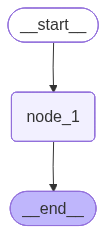

TypeError occurred: can only concatenate list (not "NoneType") to list


In [16]:
def reduce_list(left: list | None, right: list | None) -> list:
    """
    Safely combine two lists, handling cases where either or both inputs might be None.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# Build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo": None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")


Now, let's try with our custom reducer. We can see that no error is thrown.

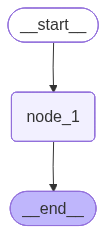

---Node 1---
{'foo': [2]}


In [17]:
# Build graph
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo": None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

## Messages
In module 1, we showed how to use built-in reducer, `add_messages`, to handle messages in state.

We also showed that `MessagesState` is a useful shortcut if you want to work with messages.
- `MessagesState` has a built-in `message` key.
- It also has a built-in `add_messages` reducer for this key.

These two are equivalent.

In [18]:
from typing import Annotated
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage

# Define a custom TypedDict that includes a list of messages with add_messages reducer
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str

# Use MessagesState, which includes the messages key with add_messages reducer
class ExtendedMessagesState(MessagesState):
    added_key_1: str
    added_key_2: str

# Initial State
initial_messages = [
    AIMessage(content="Hello! How can I assist you?", name="Model"),
    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")        
]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='44aa22c9-c98d-413a-b4a1-3cd0a48e1d4b', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='4154d178-ae82-4fdc-8780-1c74d37f1a52'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='acb49855-7021-46a8-b1a9-1bc525e3f872', tool_calls=[], invalid_tool_calls=[])]

### Re-writing
Let's show some useful tricks when working with the `add_messages` reducer.

If we pass a message with the same ID as an existing one in our `messages` list, it will get overwritten.

In [19]:
# Initial State
initial_messages = [
    AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
    HumanMessage(content="I'm looking for information on marine biology.", name="Lance", id="2")        
]

# New message to add
new_message = HumanMessage(content="I'm looking for information on whales, specifically.", name="Lance", id="2")
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically.", additional_kwargs={}, response_metadata={}, name='Lance', id='2')]

### Removal
We can remove messages by using `RemoveMessage`.

In [20]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi!", name="Bot", id="1")]
messages.append(HumanMessage("Hi!", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whale. But what others should I learn about?", name="Lance", id="4"))

delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages) 

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]
